In [25]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [26]:
use_gpu=True                                                                                                                                       
T = 3/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [27]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [28]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [29]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

# no noise check

In [30]:


loglike_obj = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), 

In [31]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=5.845, rho=2.418
  Mode 1: <hf|hf>_timemax=26.32, rho=5.131
  Mode 2: <hf|hf>_timemax=175, rho=13.23
  Mode 3: <hf|hf>_timemax=229.3, rho=15.14
  Mode 4: <hf|hf>_timemax=148.7, rho=12.19
  Mode 5: <hf|hf>_timemax=64.29, rho=8.018
  Mode 6: <hf|hf>_timemax=21.65, rho=4.653
rho_m: [ 2.41772925  5.13076349 13.22904233 15.14144763 12.19439315  8.01801464
  4.6529207 ]
Dominant mode index: 3, rho: 15.14
beta=0.01035, rho_dom_M=15.14, rho_tot=27.47
X_scalar (time-maximized): 27.47
Time-maximized Log-likelihood: 27.1875
27.18753087538005
CPU times: user 177 ms, sys: 12.2 ms, total: 189 ms
Wall time: 213 ms


In [32]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=5.59, rho=2.364
  Mode 1: <hf|hf>_timemax=25.2, rho=5.02
  Mode 2: <hf|hf>_timemax=168.7, rho=12.99
  Mode 3: <hf|hf>_timemax=223, rho=14.93
  Mode 4: <hf|hf>_timemax=145.9, rho=12.08
  Mode 5: <hf|hf>_timemax=63.56, rho=7.972
  Mode 6: <hf|hf>_timemax=21.52, rho=4.639
rho_m: [ 2.36429844  5.01976857 12.98802015 14.93210382 12.08059461  7.97234398
  4.63858616]
Dominant mode index: 3, rho: 14.93
beta=0.01056, rho_dom_M=14.93, rho_tot=27.11
X_scalar (time-maximized): 4.917
Time-maximized Log-likelihood: 0.474767
0.47476712066184634


In [33]:
import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 3/12
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing loglike_tm...
Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 

In [34]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=5.845, rho=2.418
  Mode 1: <hf|hf>_timemax=26.32, rho=5.131
  Mode 2: <hf|hf>_timemax=175, rho=13.23
  Mode 3: <hf|hf>_timemax=229.2, rho=15.14
  Mode 4: <hf|hf>_timemax=148.7, rho=12.19
  Mode 5: <hf|hf>_timemax=64.27, rho=8.017
  Mode 6: <hf|hf>_timemax=21.64, rho=4.652
rho_m: [ 2.41767687  5.13052695 13.22779979 15.14067663 12.19362134  8.01665471
  4.65173757]
Dominant mode index: 3, rho: 15.14
beta=0.01035, rho_dom_M=15.14, rho_tot=27.46
X_scalar (time-maximized): 27.46
Time-maximized Log-likelihood: 27.1856
27.185597543386592 27.185880024040287 27.185880024040287


(None, 27.18559754338659)

In [35]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=5.559, rho=2.358
  Mode 1: <hf|hf>_timemax=24.98, rho=4.998
  Mode 2: <hf|hf>_timemax=166.5, rho=12.9
  Mode 3: <hf|hf>_timemax=218.5, rho=14.78
  Mode 4: <hf|hf>_timemax=142, rho=11.91
  Mode 5: <hf|hf>_timemax=61.45, rho=7.839
  Mode 6: <hf|hf>_timemax=20.71, rho=4.551
rho_m: [ 2.35778291  4.99803186 12.90202454 14.78150733 11.91457892  7.83921759
  4.55134331]
Dominant mode index: 3, rho: 14.78
beta=0.01076, rho_dom_M=14.78, rho_tot=26.82
X_scalar (time-maximized): 5.638
Time-maximized Log-likelihood: 0.70332
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=5.562, rho=2.358
  Mode 1: <hf|hf>_timemax=24.99, rho=4.999
  Mode 2: <hf|hf>_timemax=166.5, rho=12.91
  Mode 3: <hf|hf>_timemax=218.6, rho=14.79
  Mode 4: <hf|hf>_timemax=142, rho=11.92
  Mode 5: <hf|hf>_timemax=61.48, rho=7.841
  Mode 6: <hf|hf>_timemax=20.73, rho=4.553
rho_m: [ 2.35837494  4.99934776 12.90524921 14.78503071 11.91736593  7.84109141
 

In [ ]:
import matplotlib.pyplot as plt

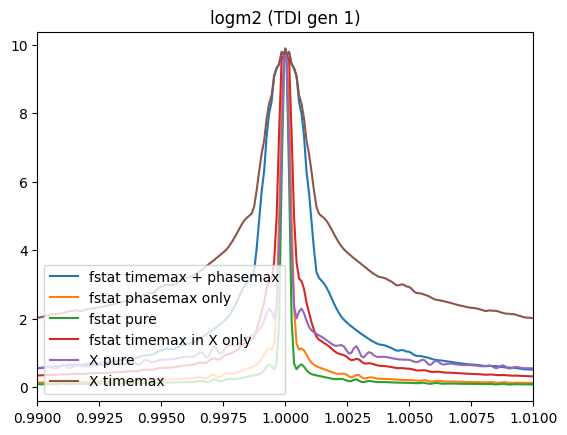

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

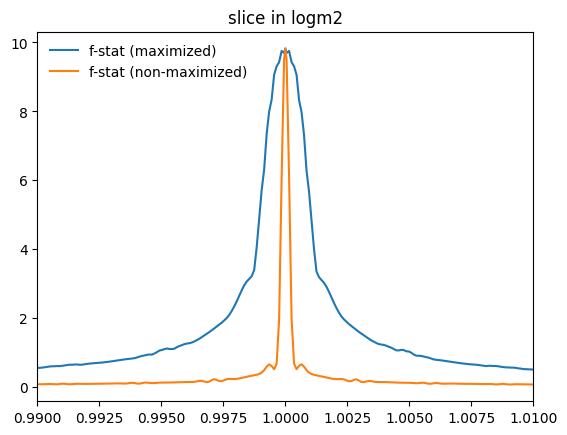

In [ ]:
plt.plot(param_range, f_stats_tm,   label='f-stat (maximized)')
# plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='f-stat (non-maximized)')
# plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
# plt.plot(param_range, X_pure, label='X pure')
# plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('slice in logm2')
plt.legend(loc='upper left', frameon=False)
plt.show()

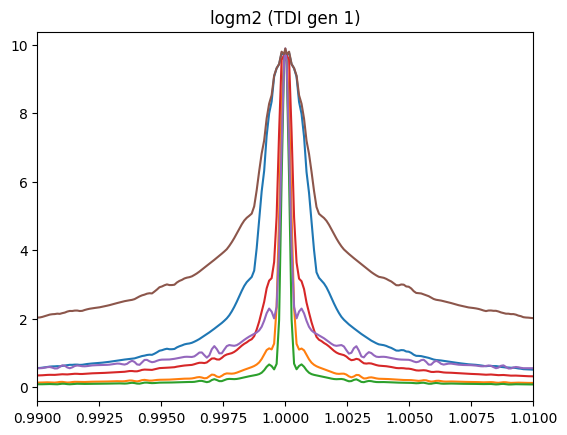

In [14]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()

# check with noise/

In [ ]:


loglike_obj_noise = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

In [ ]:
#loglike at true param
logl_true_noise=loglike_obj_noise(params)
print(logl_true_noise)

In [ ]:
                                                                                                                                                                                       
logl_perturbed_noise = loglike_obj_noise(params_perturbed)                                                                                                                                                                               
print(logl_perturbed_noise)

# 1 yr with noise

In [ ]:
gwf_1yr=GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)
waveform_response_1yr = build_waveform_response(T=1, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    

loglike_1yr = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response_1yr,                                                                                                                                                                            
    gwf=gwf_1yr,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

In [ ]:
#loglike at true param
logl_1yr=loglike_1yr(params)
print(logl_1yr)

# check orthogonality

In [ ]:
waveforms_per_group = []
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
waveforms = [   
    cp.array(waveform_response(*params, T=T, dt=dt, mode_selection=g, include_minus_mkn=False))                                                                                    
    for g in groups                                                                                                                                                                
]

In [ ]:
n = len(groups)                                                                                                                                                                    
overlap_matrix = np.zeros((n, n))
                                                                                                                                                                                    
for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])                                                                                                                                         
        overlap_matrix[i, j] = float(cp.real(gwf.overlap(hi_f, hj_f)))   

In [ ]:
# Display as heatmap
labels = [                                                                                                                                                                                       
    r'$\sum_m h_{2,m,-1}$',                                                      
    r'$\sum_m h_{2,m,0}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,1}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,2}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,3}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,4}$',                                                                                                                                                                       
    r'$\sum_m h_{2,m,5}$',
]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                             
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)                                                                                                                                
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_title('Overlap matrix TDI gen 1')                                                                                                                                          
plt.colorbar(im, ax=ax)
for i in range(n):                                                                                                                                                                 
    for j in range(n):                                                                                                                                                             
        ax.text(j, i, f'{overlap_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()                                                                                                                                                                 
plt.show() 

In [ ]:
overlap_matrix

# conditionals 3 mth

In [ ]:
  import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 3/12
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [ ]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

In [ ]:
param_true

In [ ]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

In [ ]:
def get_separatrix(a, e0):
    from few.utils.geodesic import get_separatrix
    return get_separatrix(a, e0, 1.0)  # xI=1 (prograde)

In [ ]:
get_separatrix(0.335, 0.347)

In [ ]:
f_stats_tmX

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

In [ ]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()